In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [ ]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002652237BDA0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000265224F89B0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

###  **Pydantic Schema**

In [3]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the post")
    post: str = Field(description="The LinkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post")

In [5]:
def create_post(state: graph_schema) -> graph_schema:

    # topic = state.topic

    # post = llm.invoke(f"Write a LinkedIn post about {topic}").content

    # state.post = post

    # return state

    ### Converting pydantic to dict format
    state = state.model_dump()
    topic = state['topic']

    post = llm.invoke(f"Write a LinkedIn post about {topic}").content

    state['post'] = post

    return state

In [6]:
def curate_post(state: graph_schema) -> graph_schema:
    state = state.model_dump()

    post = state['post']

    curated_post = llm.invoke(f"Curate the given post: {post}").content

    state['curated_post'] = curated_post

    return state

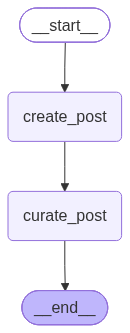

In [8]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()

Image(pydantic_graph.get_graph().draw_mermaid_png())

In [9]:
pydantic_graph.invoke({
    "topic":"The importance of AI in present world",
    "post":"",
    "curated_post":""
})

{'topic': 'The importance of AI in present world',
 'post': '🌟 **The Power of AI in Today’s World – Why It Matters More Than Ever** 🌟  \n\nFrom the moment we wake up to the time we log off, artificial intelligence is quietly reshaping the way we live, work, and solve the biggest challenges of our time. Here are three reasons why AI is no longer a “nice‑to‑have” but a **must‑have** for businesses and societies alike:\n\n1️⃣ **Accelerating Innovation**  \n🔬 In healthcare, AI‑driven diagnostics cut down disease detection time from weeks to minutes, saving lives.  \n🚀 In R&D, generative models help scientists prototype new materials and drugs at unprecedented speed.  \n\n2️⃣ **Boosting Efficiency & Decision‑Making**  \n📊 Finance firms leverage AI for real‑time risk analysis, fraud detection, and personalized client insights.  \n🛠️ Manufacturing plants use predictive maintenance to slash downtime and reduce waste.  \n\n3️⃣ **Addressing Global Challenges**  \n🌍 Climate‑tech startups harness 